# Comparing many means with ANOVA

---

#### Summary videos

- [ANOVA introduction](https://youtu.be/W36DMVJ4Ibo?si=NulRSdro7fZt9FjH) (10 minutes)
- [Conditions for ANOVA](https://youtu.be/HGFiWMA5OC8?si=p8yrzg4RoaAYJftN) (3 minutes)
- [Multiple comparisons / multiple testing](https://youtu.be/THG0P3YNbdI?si=P7oJQXJEIfW9e_ww) (7 minutes)

#### Walkthrough videos

- [Comparing many means](https://drive.google.com/file/d/1CEd8SXtSjvDdjYd1IBrmtxeav34FutYs/view?usp=sharing) (11 minutes)
- [ANOVA and the $F$-test](https://drive.google.com/file/d/1cBhQbsnriSBNvtpaLWYEpzLNbj4g8erl/view?usp=sharing) (14 minutes)
- [Multiple comparisons](https://drive.google.com/file/d/1eEB48NN3Bp1xvxA0QYqFeOzNTQY0-y72/view?usp=sharing) (9 minutes)

---

What can we do if there are more than two groups whose means we would like to compare? This requires ANOVA, which stands for

- **An**alysis
- **O**f
- **Va**riance.

Similar to how the $\chi^2$ test statistic was developed to help us compare more than two proportions, ANOVA involves a new test statistic called the $F$ statistic and its corresponding distribution (called the $F$-distribution)

## Is batting performance related to player position in MLB?

As an example, let's see if we can determine whether we can see significant differences in batting performance of MLB players according to their position

- Outfielder (OF)
- Infielder (IF)
- Catcher (C).

We'll load some data from the 2018 season. The `bat18` dataset contains records fro 429 MLB players who were at bat at least 100 times.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd

mlb_players_18 = pd.read_csv('https://raw.githubusercontent.com/clarkti5/math-209-data-sets/refs/heads/main/mlb_players_18.csv')

bat100 = mlb_players_18[mlb_players_18['AB'] >= 100]
bat100['position'].replace(['LF', 'CF', 'RF'], 'OF', inplace = True)
bat100['position'].replace(['1B', '2B', '3B', 'SS'], 'IF', inplace = True)
bat100.drop(bat100[bat100['position'] == 'DH'].index, inplace = True)
bat100.drop(bat100[bat100['position'] == 'P'].index, inplace = True)
bat100.head()

We can compare the average on-base percentage (`OBP`) for each group.

In [ ]:
x_bar_OF = bat100[bat100['position'] == 'OF']['OBP'].mean()
x_bar_IF = bat100[bat100['position'] == 'IF']['OBP'].mean()
x_bar_C = bat100[bat100['position'] == 'C']['OBP'].mean()

sd_OF = bat100[bat100['position'] == 'OF']['OBP'].std()
sd_IF = bat100[bat100['position'] == 'IF']['OBP'].std()
sd_C = bat100[bat100['position'] == 'C']['OBP'].std()

n_OF = len(bat100[bat100['position'] == 'OF'])
n_IF = len(bat100[bat100['position'] == 'IF'])
n_C = len(bat100[bat100['position'] == 'C'])

print(f"Outfielder sample size: {n_OF}")
print(f"Outfielder mean: {round(x_bar_OF,4)}")
print(f"Outfielder standard deviation: {round(sd_OF,4)}")
print("---")
print(f"Infielder sample size: {n_IF}")
print(f"Infielder mean: {round(x_bar_IF,4)}")
print(f"Infielder standard deviation: {round(sd_IF,4)}")
print("---")
print(f"Catcher sample size: {n_C}")
print(f"Catcher mean: {round(x_bar_C,4)}")
print(f"Catcher standard deviation: {round(sd_C,4)}")

In [ ]:
from plotnine import *

(
  ggplot(bat100) +
  aes(x = bat100['position'], y = bat100['OBP']) +
  geom_boxplot() +
  labs(x = 'Position', y = 'On-base percentage')
)

### Questions

- Based on the numerical summary and plot above, does there appear to be a difference in on-base percentage as related to position?

- If so, which pairs of positions have the largest discernable difference?

- Is it reasonable to proceed by *only* testing for a difference between the those two groups?

  - ```Hint: consider the Type I Error rate.```

### Exercise

To make things formal, we should create hypotheses.

- Describe the null hypothesis in this situation.
- Describe the alternative hypothesis.

#### Solution

- $H_0$: Mean OBP does not vary significantly across player position.
$$\boxed{\mu_{OF} = \mu_{IF} = \mu_{C}}$$
- $H_A$: Mean OBP does vary significantly across player position. At least one of $\mu_{OF}$, $\mu_{IF}$, and $\mu_{C}$ is different from the others.

## ANOVA and the $F$-test

We must find a way to *simultaneously* consider many groups and determine if their sample means differ more than we would expect from natural variation.

The variability between groups in this case is called the **mean square between groups**, denoted **MSG**. It is computed in terms of the square difference between the sample means with the mean across all groups. Details can be found in a footnote on page 289 of the textbook.

The **mean square error** (**MSE**) is a similar number computed as a pooled variance, meant to quantify the variability *within* groups (as opposed to between groups). If the null hypothesis is true, the **MSE** should be about equal to the **MSG**.

The $F$-statistic is the ratio of these values

$$ F = \dfrac{MSG}{MSE}. $$



### Question

Assuming the null hypothesis is true, what should we expect for the value of $F$?

The conditions that must be met before proceeding with ANOVA are summarized on page 291 of the textbook. They include

- **Indepdendence.** Observations should be independent, e.g., from a random sample.

- **Approximately normal.** Small samples ($n < 30$) should follow a nearly normal distribution. Large samples ($n \geq 30$) should avoid particularly extreme outliers.

- **Constant variance.** The variance within each group should be about equal from one group to the next.

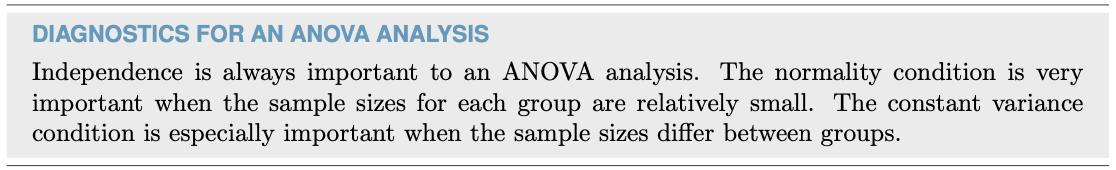

Below is a histogram for the on-base percentages for each group under consideration.

In [ ]:
(
  ggplot(bat100) +
  aes(x = bat100['OBP']) +
  geom_histogram(binwidth = 0.025) +
  facet_wrap('position')
)

### Question

Are the independence, normality, and constant variance conditions reasonably satisfied for our baseball data?

The `scipy.stats` package provides a built-in function to perform an $F$-test across one categorical variable called `f_oneway`.

In [ ]:
# This code performs ANOVA to find F and its p-value.

from scipy.stats import f_oneway

ANOVA = f_oneway(
  bat100[bat100['position'] == 'OF']['OBP'],
  bat100[bat100['position'] == 'IF']['OBP'],
  bat100[bat100['position'] == 'C']['OBP']
)

print(f"F-statistic: {ANOVA[0]}")
print(f"p-value: {ANOVA[1]}")

In [ ]:
# This is another way to do it that also prints the MSG and MSE.

import statsmodels.api as sm
from statsmodels.formula.api import ols

def ANOVA(data, response_variable, predictor_variable):
  input_string = response_variable + '~' + predictor_variable
  model = ols(input_string, data = data).fit()
  return sm.stats.anova_lm(model)

In [ ]:
ANOVA(bat100, 'OBP', 'position')

Below is a description of the elements of this output table.

|          | df                                  | sum_sq | mean_sq | F       | PR(>F)       |
|----------|-------------------------------------|--------|---------|---------|--------------|
| variable | dfG = (# of groups) - 1             | SSG    | MSG = SSG/dfG| MSG/MSE | p-value of F |
| Residual | dfE = (sample size) - (# of groups) | SSE    | MSE = SSE/dfE|         |              |

> - The two degrees of freedom add up to $(\text{sample size}) - 1$.
> - `SSG` stands for "sum of squares between groups" and `SSE` stands for "sum of squared errors".
> - `MSG` is the `SSG` divided by the `df` from its row.
> - `MSE` is the `SSE` divided by the `df` from its row.
> - `F` is `MSG` divided by `MSE`.

Some software will also include a `Totals` row for the `df` and `sum_sq` columns.

|          | df                                  | sum_sq | mean_sq | F       | PR(>F)       |
|----------|-------------------------------------|--------|---------|---------|--------------|
| variable | dfG = (# of groups) - 1             | SSG    | MSG = SSG/dfG| MSG/MSE | p-value of F |
| Residual | dfE = (sample size) - (# of groups) | SSE    | MSE = SSE/dfE|         |              |
| Totals   | dfG + dfE = (sample size) - 1 | SST = SSG + SSE |

### Exercise

Verify these features using the numbers from the `bat100` ANOVA table above.

In [ ]:
dfG = 2.0
dfE = 426

SSG = 0.016063
SSE = 0.673950

print(f"MSG = {SSG/dfG}")
print(f"MSE = {SSE/dfE}")

### Question

- Is this $F$ value what we should expect from the null hypothesis?

- Use the p-value computed above to draw an appropriate conclusion for our hypothesis test.

### Exercise

The p-value is computed according to the $F$-distribution.

- Use [GeoGebra](https://geogebra.org/classic#probability) to visualize the $F$-distribution for our baseball data.
  - Note, $df_1$ is the degrees of freedom corresponding to the MSG calculation, which is 1 less than the number of groups being compared (i.e. `dfG` from above).
  - Meanwhile, $df_2$ is the degrees of freedom corresponding to the MSE calculation, which is the total sample size minus the number of groups (i.e. `dfE` from above).
- Use this $F$-distribution to confirm the p-value calculated above.

## Multiple comparisons and controlling for Type I Error rate

We were able to reject our null hypothesis that the mean on-base percentages of all three positions were equal to one another. However, that doesn't actually tell us *which means* were different! It's possible that only one of the means differs significantly from the other two (which one!?), or that all three are distinct from each other.

It is possible to use a two-sample $t$-test to compare the means pairwise, as done in Section 7.3

### Exercise

- How many $t$-tests would we need to perform in the case of our 3 baseball position on-base percentage means ($\mu_{OF}, \mu_{IF}, \mu_{C}$)?

- Each time we run one of these $t$-tests, there is a chance that we commit a Type I Error. How likely is it that we can *avoid* a Type I Error in all of the tests described above?

- In general, as the number of tests performed increases, how does the liklihood of committing a Type I Error change?


This situation is rectified using something called the **Bonferroni correction** for multiple comparisons, as seen on page 293 of the textbook.

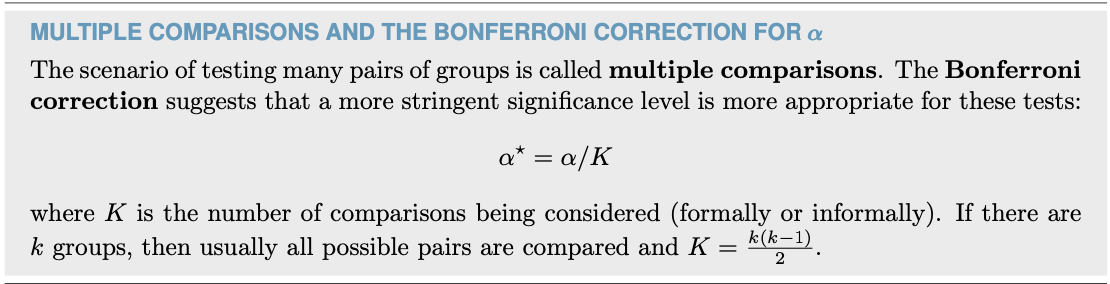

### Example

Perform the three pairwise comparisons for the on-base percentages across positions described above using the Bonferroni correction and report the findings.

First, let's determine $\alpha^*$ based on $\alpha = 0.05$. Since we are making 3 comparisons, we find

$$ \alpha^* = \dfrac{0.05}{3} \approx 0.0167 $$

### Exercise

- With $\alpha^* = 0.0167$, how likely is it that we avoid a Type I error in all three $t$-tests?

- How does this compare to the original significance level of $\alpha = 0.05$?

In [ ]:
# Probability of avoiding a Type I error in three consecutive t-tests
# using alpha = 0.0167

(1 - 0.0167)**3

#### OF vs IF

Run the code below to perform the $t$-test and interpret the results.

In [ ]:
import math
import scipy.stats as stats

alpha = 0.05
K = 3
alpha_star = alpha/K
null_diff = 0

x_diff = x_bar_OF - x_bar_IF

SE = math.sqrt(sd_OF**2/n_OF + sd_IF**2/n_IF)

T = (x_diff - null_diff)/SE
df = min(n_OF - 1, n_IF - 1)

p = 2*(1-stats.t.cdf(abs(T), df=df))

print(f"T-score: {T}")
print(f"p-value: {p}")

if p < alpha_star:
    print("Reject null hypothesis")
else:
    print("Fail to reject null hypothesis")

#### OF vs C

Run the code below to perform the $t$-test and interpret the results.

In [ ]:
alpha = 0.05
K = 3
alpha_star = alpha/K
null_diff = 0

x_diff = x_bar_OF - x_bar_C

SE = math.sqrt(sd_OF**2/n_OF + sd_C**2/n_C)

T = (x_diff - null_diff)/SE
df = min(n_OF - 1, n_C - 1)

p = 2*(1-stats.t.cdf(abs(T), df=df))

print(f"T-score: {T}")
print(f"p-value: {p}")

if p < alpha_star:
    print("Reject null hypothesis")
else:
    print("Fail to reject null hypothesis")

#### IF vs C

Run the code below to perform the $t$-test and interpret the results.

In [ ]:
alpha = 0.05
K = 3
alpha_star = alpha/K
null_diff = 0

x_diff = x_bar_IF - x_bar_C

SE = math.sqrt(sd_IF**2/n_IF + sd_C**2/n_C)

T = (x_diff - null_diff)/SE
df = min(n_IF - 1, n_C - 1)

p = 2*(1-stats.t.cdf(abs(T), df=df))

print(f"T-score: {T}")
print(f"p-value: {p}")

if p < alpha_star:
    print("Reject null hypothesis")
else:
    print("Fail to reject null hypothesis")

---

This notebook was written by Timothy L. Clark, derivative of [OpenIntro Statistics by Diez, Çetinkaya-Rundel, and Barr](https://www.openintro.org/book/os/), released under [Creative Commons BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/deed.en) license.

